In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import pickle
import time
from datetime import datetime

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/fhe_dataset/final_dataset/ml_training_data.csv')

In [4]:
FEATURE_COLS = [
        # Operation details
        'operation_type_encoded',
        'is_multiplication',
        'is_addition',
        'is_square',
        'is_scalar_mult',
        'num_inputs',
        'op_input_magnitude',
        'op_output_magnitude',

        # Circuit context
        'multiplicative_depth',
        'position_in_circuit_norm',
        'op_index_from_end',
        'operations_since_bootstrap',
        'time_since_last_bootstrap',
        'bootstrap_count_so_far',
        'cumulative_operations',
        'cum_ops_normalized',

        # CKKS parameters
        'poly_modulus_degree',
        'global_scale_log2',
        'complexity_encoded',
        'circuit_type_encoded',

        # Noise history
        'cumulative_noise',
        'delta_decryption_error',
        'delta_cumulative_noise',

        # Rolling features
        'rolling_avg_decryption_error_3',
        'rolling_max_decryption_error_3',
        'rolling_count_mult_3',
        'rolling_prop_mult_3',
        'rolling_avg_op_time_3',

        # Sequence features
        'prev_op_type_encoded',
        'prev2_op_type_encoded',

        # Derived features
        'mult_depth_times_op_time',
        'mult_depth_ratio',

        # Circuit-level
        'circuit_length',
        'start_noise_proxy'
    ]

TARGET_COL = "noise_proxy"

available_features = [f for f in FEATURE_COLS if f in df.columns]
missing_features = [f for f in FEATURE_COLS if f not in df.columns]

if missing_features:
    print(f"   ⚠️  Missing features: {missing_features}")
print(f"   ✅ Using {len(available_features)} features")
X = df[available_features].values
y_regression = df[TARGET_COL].values


print("\n Splitting by circuits...")
circuits = df['circuit_id'].values
unique_circuits = df['circuit_id'].unique()
print(f"   ✅ Found {len(unique_circuits)} unique circuits")

# Training parameters
TEST_SIZE = 0.2
VALIDATION_SIZE = 0.1
RANDOM_STATE = 42

from sklearn.model_selection import train_test_split

# Split circuits into train/val/test
train_circuits, temp_circuits = train_test_split(
    unique_circuits,
    test_size=TEST_SIZE + VALIDATION_SIZE,
    random_state=RANDOM_STATE
)

val_circuits, test_circuits = train_test_split(
    temp_circuits,
    test_size=TEST_SIZE / (TEST_SIZE + VALIDATION_SIZE),
    random_state=RANDOM_STATE
)

# Create masks
train_mask = np.isin(circuits, train_circuits)
val_mask = np.isin(circuits, val_circuits)
test_mask = np.isin(circuits, test_circuits)

# Split data
X_train, X_val, X_test = X[train_mask], X[val_mask], X[test_mask]
y_train, y_val, y_test = y_regression[train_mask], y_regression[val_mask], y_regression[test_mask]

print(f"   Train: {len(X_train)} ops from {len(train_circuits)} circuits")
print(f"   Val:   {len(X_val)} ops from {len(val_circuits)} circuits")
print(f"   Test:  {len(X_test)} ops from {len(test_circuits)} circuits")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

results = []

   ✅ Using 34 features

 Splitting by circuits...
   ✅ Found 8100 unique circuits
   Train: 21792 ops from 5669 circuits
   Val:   3115 ops from 810 circuits
   Test:  6277 ops from 1621 circuits


In [5]:
# ML EVAL Libraries
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                            explained_variance_score, median_absolute_error)


def get_regression_metrics(model, y_test, y_pred):
    """
    Calculates various regression metrics for a given model's predictions.

    Args:
        model: The trained regression model.
        y_test (np.ndarray): The true target values.
        y_pred (np.ndarray): The predicted values from the model.

    Returns:
        dict: A dictionary containing the calculated regression metrics.
    """
    metrics = {
        'model_name': type(model).__name__,
        'mse': mean_squared_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae': mean_absolute_error(y_test, y_pred),
        'r2': r2_score(y_test, y_pred),
        'explained_variance': explained_variance_score(y_test, y_pred),
        'median_absolute_error': median_absolute_error(y_test, y_pred)
    }
    return metrics

In [6]:
# Model Libraries
from sklearn.linear_model import LinearRegression, Ridge, Lasso

linear_regressor=LinearRegression()
ridge_regressor=Ridge()
lasso_regressor=Lasso()

linear_regressor.fit(X_train, y_train)
ridge_regressor.fit(X_train, y_train)
lasso_regressor.fit(X_train, y_train)


linear_regressor_metrics = get_regression_metrics(linear_regressor, y_test, linear_regressor.predict(X_test))
results.append(linear_regressor_metrics)
ridge_regressor_metrics = get_regression_metrics(ridge_regressor, y_test, ridge_regressor.predict(X_test))
results.append(ridge_regressor_metrics)
lasso_regressor_metrics = get_regression_metrics(lasso_regressor, y_test, lasso_regressor.predict(X_test))
results.append(lasso_regressor_metrics)

results_df = pd.DataFrame(results)
results_df

,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,0.663955,0.814834,0.264794,0.935028,0.935028,0.140592
1,Ridge,0.656468,0.810227,0.264855,0.935760,0.935892,0.147259
2,Lasso,0.810704,0.900391,0.244180,0.920667,0.922700,0.208426


In [7]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor

decision_tree_default = DecisionTreeRegressor()
random_forest_default = RandomForestRegressor(verbose=3,n_jobs=-1)
gradient_boosting_default = GradientBoostingRegressor(verbose=3)
adaboost_default = AdaBoostRegressor()

print("training decision tree")
decision_tree_default.fit(X_train, y_train)

print("training random forest")
random_forest_default.fit(X_train, y_train,)

print("training gradent boost")
gradient_boosting_default.fit(X_train, y_train)
print("training adaboost")
adaboost_default.fit(X_train, y_train)


decision_tree_metrics = get_regression_metrics(decision_tree_default, y_test, decision_tree_default.predict(X_test))
results.append(decision_tree_metrics)
random_forest_metrics = get_regression_metrics(random_forest_default, y_test, random_forest_default.predict(X_test))
results.append(random_forest_metrics)
gradient_boosting_metrics = get_regression_metrics(gradient_boosting_default, y_test, gradient_boosting_default.predict(X_test))
results.append(gradient_boosting_metrics)
adaboost_metrics = get_regression_metrics(adaboost_default, y_test, adaboost_default.predict(X_test))
results.append(adaboost_metrics)

results_df = pd.DataFrame(results)
results_df


training decision tree
training random forest
building tree 1 of 100
building tree 2 of 100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100


[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:   17.4s


building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.1min finished


training gradent boost
      Iter       Train Loss   Remaining Time 
         1     3862879.5949           14.64s
         2     3128976.1364           14.25s
         3     2534514.3350           14.00s
         4     2052992.5148           13.91s
         5     1662958.0512           13.74s
         6     1347024.4161           13.57s
         7     1091117.1960           13.63s
         8      883828.1104           13.51s
         9      715923.4913           13.34s
        10      579917.5937           13.17s
        11      469752.6748           12.98s
        12      380516.7266           12.84s
        13      308234.8159           12.68s
        14      249684.6246           12.60s
        15      202258.4632           12.42s
        16      163837.0128           12.27s
        17      132715.4582           12.12s
        18      107506.8604           11.98s
        19       87087.5983           12.08s
        20       70547.7145           12.14s
        21       57150.2918    

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.2s finished


,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,0.663955,0.814834,0.264794,0.935028,0.935028,0.140592
1,Ridge,0.656468,0.810227,0.264855,0.935760,0.935892,0.147259
2,Lasso,0.810704,0.900391,0.244180,0.920667,0.922700,0.208426
3,DecisionTreeRegressor,1.191183,1.091413,0.034847,0.883435,0.883437,0.000006
4,RandomForestRegressor,5.521640,2.349817,0.045813,0.459671,0.459801,0.000004
5,GradientBoostingRegressor,0.282966,0.531946,0.075096,0.972310,0.972310,0.045231
6,AdaBoostRegressor,15.401928,3.924529,2.556713,-0.507181,0.015195,2.511941


In [8]:
decision_tree_default.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [9]:
stop

NameError: name 'stop' is not defined

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
import json

# Define the parameter grid
param_grid_dt = {
    # 'max_depth': [None, 10, 20, 30],
    # 'max_features': [5, 10,15, 20,25, 30],
    # 'min_samples_split': [2, 5, 10],
    # 'min_samples_leaf': [1, 2, 4],
    'criterion':[ 'absolute_error', 'poisson', 'squared_error', 'friedman_mse'],
    # 'max_leaf_nodes' : [2,4,6,8,10],
}

# Create a Decision Tree Regressor model
dt = DecisionTreeRegressor(random_state=RANDOM_STATE)

# Create the GridSearchCV object
grid_search_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt,
                           scoring='neg_mean_squared_error', cv=3, verbose=3,)

# Fit the grid search to the training data
print("Performing Grid Search for Decision Tree Regressor...")
grid_search_dt.fit(X_train, y_train)

# Print the best parameters and the best score
print("\nBest parameters found: ", grid_search_dt.best_params_)
print("Best RMSE found: ", np.sqrt(-grid_search_dt.best_score_))

# Get the best model
decision_tree_best = grid_search_dt.best_estimator_

# Evaluate the best model on the test set
y_pred_dt_grid = decision_tree_best.predict(X_test)
dt_grid_metrics = get_regression_metrics(decision_tree_best, y_test, y_pred_dt_grid)

results.append(dt_grid_metrics)

results_df = pd.DataFrame(results)
display(results_df)

# Save the best parameters to a text file
output_dir = Path("/content/drive/MyDrive/models/noise_predictor/all_complexity") # Assuming 'all_complexity' as the default output dir
output_dir.mkdir(parents=True, exist_ok=True)
best_params_path = output_dir / "decision_tree_best_params.txt"

with open(best_params_path, 'a') as f:
    json.dump(grid_search_dt.best_params_, f, indent=4)

print(f"\nBest parameters saved to: {best_params_path}")

In [ ]:
random_forest_default.get_params()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import json

# Define the parameter grid
param_grid_rf = {
    # 'max_depth': [None, 10, 20, 30],
    # 'max_features': [5, 10,15, 20,25, 30],
    # 'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    # 'n_estimators': [100, 200, 300],
    # 'max_leaf_nodes': [None,2,4,6,8],
    # 'criterion':[ 'squared_error', 'absolute_error', 'poisson', 'friedman_mse'],
}


# Create a random forest Regressor model
rf = RandomForestRegressor(random_state=RANDOM_STATE)

# Create the GridSearchCV object
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf,
                           scoring='neg_mean_squared_error', cv=3, verbose=3,)#n_jobs=-1)

# Fit the grid search to the training data
print("Performing Grid Search for Random Forest Regressor...")
grid_search_rf.fit(X_train, y_train)

# Print the best parameters and the best score
print("\nBest parameters found: ", grid_search_rf.best_params_)
print("Best RMSE found: ", np.sqrt(-grid_search_rf.best_score_))

# Get the best model
random_forest_best = grid_search_rf.best_estimator_

# Evaluate the best model on the test set
y_pred_rf_grid = random_forest_best.predict(X_test)
rf_grid_metrics = get_regression_metrics(random_forest_best, y_test, y_pred_rf_grid)

results.append(rf_grid_metrics)

results_df = pd.DataFrame(results)
display(results_df)

# Save the best parameters to a text file
output_dir = Path("/content/drive/MyDrive/models/noise_predictor/all_complexity") # Assuming 'all_complexity' as the default output dir
output_dir.mkdir(parents=True, exist_ok=True)
best_params_path = output_dir / "random_forest_best_params.txt"

with open(best_params_path, 'a') as f:
    json.dump(grid_search_rf.best_params_, f, indent=4)

print(f"\nBest parameters saved to: {best_params_path}")

In [ ]:
gradient_boosting_default.get_params()

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import json
from pathlib import Path

param_grid_gb = {
    # 'max_depth': [None, 10, 20, 30],
    # 'max_features': [5, 10,15, 20,25, 30],
    # 'alpha': [0.001, 0.01, 0.1],
    # 'n_estimators': [100, 200, 300],
    # 'learning_rate': [0.001, 0.01, 0.1, 1.0],
    # 'loss': ['squared_error', 'quantile', 'huber', 'absolute_error'],
    'max_leaf_nodes': [None, 10, 20, 30],
}
gb = GradientBoostingRegressor(random_state=RANDOM_STATE)

grid_search_gb = GridSearchCV(estimator=gb, param_grid=param_grid_gb,
                           scoring='neg_mean_squared_error', cv=3, verbose=3,)

print("Performing Grid Search for Gradient Boosting Regressor...")
grid_search_gb.fit(X_train, y_train)

print("\nBest parameters found: ", grid_search_gb.best_params_)
print("Best RMSE found: ", np.sqrt(-grid_search_gb.best_score_))

gradient_boosting_best = grid_search_gb.best_estimator_

y_pred_gb_grid = gradient_boosting_best.predict(X_test)
gb_grid_metrics = get_regression_metrics(gradient_boosting_best, y_test, y_pred_gb_grid)

results.append(gb_grid_metrics)

results_df = pd.DataFrame(results)
display(results_df)


# Save the best parameters to a text file
output_dir = Path("/content/drive/MyDrive/models/noise_predictor/all_complexity") # Assuming 'all_complexity' as the default output dir
output_dir.mkdir(parents=True, exist_ok=True)
best_params_path = output_dir / "gradient_boosting_best_params.txt"

with open(best_params_path, 'a') as f:
    json.dump(grid_search_gb.best_params_, f, indent=4)


print(f"\nBest parameters saved to: {best_params_path}")

In [ ]:
adaboost_default.get_params()

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV
import json
from pathlib import Path

param_grid_ada = {
    'learning_rate': [0.001, 0.01, 0.1, 1.0],
    'loss': ['linear', 'square', 'exponential'], # Corrected loss values
    'n_estimators': [100, 200, 300],
}

ada = AdaBoostRegressor(random_state=RANDOM_STATE)

grid_search_ada = GridSearchCV(estimator=ada, param_grid=param_grid_ada,
                           scoring='neg_mean_squared_error', cv=3, verbose=3,)
print("Performing Grid Search for AdaBoost Regressor...")
grid_search_ada.fit(X_train, y_train)

print("\nBest parameters found: ", grid_search_ada.best_params_)
print("Best RMSE found: ", np.sqrt(-grid_search_ada.best_score_))

adaboost_best = grid_search_ada.best_estimator_

y_pred_ada_grid = adaboost_best.predict(X_test)
ada_grid_metrics = get_regression_metrics(adaboost_best, y_test, y_pred_ada_grid)

results.append(ada_grid_metrics)
results_df = pd.DataFrame(results)
results_df

# Save the best parameters to a text file
output_dir = Path("/content/drive/MyDrive/models/noise_predictor/all_complexity") # Assuming 'all_complexity' as the default output dir
output_dir.mkdir(parents=True, exist_ok=True)
best_params_path = output_dir / "adaboost_best_params.txt"

with open(best_params_path, 'w') as f:
    json.dump(grid_search_ada.best_params_, f, indent=4)

print(f"\nBest parameters saved to: {best_params_path}")

In [10]:
from sklearn.svm import SVR

svr_basci = SVR()
svr_basci.fit(X_train, y_train)
y_pred_svr_basci = svr_basci.predict(X_test)
svr_basci_metrics = get_regression_metrics(svr_basci, y_test, y_pred_svr_basci)
results.append(svr_basci_metrics)
results_df = pd.DataFrame(results)
results_df

,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,0.663955,0.814834,0.264794,0.935028,0.935028,0.140592
1,Ridge,0.656468,0.810227,0.264855,0.935760,0.935892,0.147259
2,Lasso,0.810704,0.900391,0.244180,0.920667,0.922700,0.208426
3,DecisionTreeRegressor,1.191183,1.091413,0.034847,0.883435,0.883437,0.000006
4,RandomForestRegressor,5.521640,2.349817,0.045813,0.459671,0.459801,0.000004
5,GradientBoostingRegressor,0.282966,0.531946,0.075096,0.972310,0.972310,0.045231
6,AdaBoostRegressor,15.401928,3.924529,2.556713,-0.507181,0.015195,2.511941
7,SVR,9.996714,3.161758,0.203304,0.021755,0.023836,0.047375


In [ ]:
svr_basci.get_params()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
import json
from pathlib import Path

# Define the parameter grid for SVR
param_grid_svr = {
    # 'C': [0.1, 1, 10, 100],
    # 'cache_size': [200, 500, 700, 1000],
    # 'degree': [2, 3, 4],
    # 'epsilon': [0.01, 0.1, 0.5],
    # 'gamma': ['scale', 'auto'],
    # 'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'tol': [1e-3, 1e-4, 1e-5],
}

# Create an SVR model
svr = SVR()

# Create the GridSearchCV object
grid_search_svr = GridSearchCV(estimator=svr, param_grid=param_grid_svr,
                           scoring='neg_mean_squared_error', cv=3, verbose=3)

# Fit the grid search to the training data
print("Performing Grid Search for SVR Regressor...")
grid_search_svr.fit(X_train, y_train)

# Print the best parameters and the best score
print("\nBest parameters found: ", grid_search_svr.best_params_)
print("Best RMSE found: ", np.sqrt(-grid_search_svr.best_score_))

# Get the best model
svr_best = grid_search_svr.best_estimator_

# Evaluate the best model on the test set
y_pred_svr_grid = svr_best.predict(X_test)
svr_grid_metrics = get_regression_metrics(svr_best, y_test, y_pred_svr_grid)

results.append(svr_grid_metrics)

results_df = pd.DataFrame(results)
display(results_df)

# Save the best parameters to a text file
output_dir = Path("/content/drive/MyDrive/models/noise_predictor/all_complexity") # Assuming 'all_complexity' as the default output dir
output_dir.mkdir(parents=True, exist_ok=True)
best_params_path = output_dir / "svr_best_params.txt"

with open(best_params_path, 'a') as f:
    json.dump(grid_search_svr.best_params_, f, indent=4)

print(f"\nBest parameters saved to: {best_params_path}")

In [11]:
from sklearn.neighbors import KNeighborsRegressor

knn_basci = KNeighborsRegressor()
knn_basci.fit(X_train, y_train)
y_pred_knn_basci = knn_basci.predict(X_test)
knn_basci_metrics = get_regression_metrics(knn_basci, y_test, y_pred_knn_basci)
results.append(knn_basci_metrics)
results_df = pd.DataFrame(results)
results_df

,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,0.663955,0.814834,0.264794,0.935028,0.935028,0.140592
1,Ridge,0.656468,0.810227,0.264855,0.935760,0.935892,0.147259
2,Lasso,0.810704,0.900391,0.244180,0.920667,0.922700,0.208426
3,DecisionTreeRegressor,1.191183,1.091413,0.034847,0.883435,0.883437,0.000006
4,RandomForestRegressor,5.521640,2.349817,0.045813,0.459671,0.459801,0.000004
5,GradientBoostingRegressor,0.282966,0.531946,0.075096,0.972310,0.972310,0.045231
6,AdaBoostRegressor,15.401928,3.924529,2.556713,-0.507181,0.015195,2.511941
7,SVR,9.996714,3.161758,0.203304,0.021755,0.023836,0.047375
8,KNeighborsRegressor,3.696729,1.922688,0.146588,0.638250,0.638928,0.002607


In [ ]:
knn_basci.get_params()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
import json
from pathlib import Path

# Define the parameter grid for KNeighborsRegressor
param_grid_knn = {
    # 'n_neighbors': [3, 5, 7, 9],
    # 'weights': ['uniform', 'distance'],
    # 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

# Create a KNeighborsRegressor model
knn = KNeighborsRegressor()

# Create the GridSearchCV object
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn,
                           scoring='neg_mean_squared_error', cv=3, verbose=3,)

# Fit the grid search to the training data
print("Performing Grid Search for KNeighborsRegressor...")
grid_search_knn.fit(X_train, y_train)

# Print the best parameters and the best score
print("\nBest parameters found: ", grid_search_knn.best_params_)
print("Best RMSE found: ", np.sqrt(-grid_search_knn.best_score_))

# Get the best model
knn_best = grid_search_knn.best_estimator_

# Evaluate the best model on the test set
y_pred_knn_grid = knn_best.predict(X_test)
knn_grid_metrics = get_regression_metrics(knn_best, y_test, y_pred_knn_grid)

results.append(knn_grid_metrics)

results_df = pd.DataFrame(results)
display(results_df)

# Save the best parameters to a text file
output_dir = Path("/content/drive/MyDrive/models/noise_predictor/all_complexity") # Assuming 'all_complexity' as the default output dir
output_dir.mkdir(parents=True, exist_ok=True)
best_params_path = output_dir / "knn_best_params.txt"

with open(best_params_path, 'a') as f:
    json.dump(grid_search_knn.best_params_, f, indent=4)

print(f"\nBest parameters saved to: {best_params_path}")

In [12]:
import lightgbm as lgb

lighthgbm = lgb.LGBMRegressor()
lighthgbm.fit(X_train, y_train)
y_pred_lighthgbm = lighthgbm.predict(X_test)
lighthgbm_metrics = get_regression_metrics(lighthgbm, y_test, y_pred_lighthgbm)
results.append(lighthgbm_metrics)
results_df = pd.DataFrame(results)
results_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2958
[LightGBM] [Info] Number of data points in the train set: 21792, number of used features: 32
[LightGBM] [Info] Start training from score 16.260411


,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,0.663955,0.814834,0.264794,0.935028,0.935028,0.140592
1,Ridge,0.656468,0.810227,0.264855,0.935760,0.935892,0.147259
2,Lasso,0.810704,0.900391,0.244180,0.920667,0.922700,0.208426
3,DecisionTreeRegressor,1.191183,1.091413,0.034847,0.883435,0.883437,0.000006
4,RandomForestRegressor,5.521640,2.349817,0.045813,0.459671,0.459801,0.000004
5,GradientBoostingRegressor,0.282966,0.531946,0.075096,0.972310,0.972310,0.045231
6,AdaBoostRegressor,15.401928,3.924529,2.556713,-0.507181,0.015195,2.511941
7,SVR,9.996714,3.161758,0.203304,0.021755,0.023836,0.047375
8,KNeighborsRegressor,3.696729,1.922688,0.146588,0.638250,0.638928,0.002607
9,LGBMRegressor,475764.319351,689.756710,28.819281,-46555.707322,-46526.077415,0.001632


In [ ]:
lighthgbm.get_params()

In [ ]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
import json
from pathlib import Path

# Define the parameter grid for LightGBM
param_grid_lgb = {
    'boosting_type': ['gbdt', 'dart', 'goss'],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'num_leaves': [31, 64, 128],
    'max_depth': [-1, 10, 20,30],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5],
}

# Create a LightGBM Regressor model
lgbm = lgb.LGBMRegressor(random_state=RANDOM_STATE, objective='regression_l2')

for k,v in param_grid_lgb.items():

  # Create the GridSearchCV object
  grid_search_lgb = GridSearchCV(estimator=lgbm, param_grid={k:v},
                            scoring='neg_mean_squared_error', cv=3, verbose=3)

  # Fit the grid search to the training data
  print("Performing Grid Search for LightGBM Regressor...")
  grid_search_lgb.fit(X_train, y_train)

  # Print the best parameters and the best score
  print("\nBest parameters found: ", grid_search_lgb.best_params_)
  print("Best RMSE found: ", np.sqrt(-grid_search_lgb.best_score_))

  # Get the best model
  lgbm_best = grid_search_lgb.best_estimator_

  # Evaluate the best model on the test set
  y_pred_lgbm_grid = lgbm_best.predict(X_test)
  lgbm_grid_metrics = get_regression_metrics(lgbm_best, y_test, y_pred_lgbm_grid)

  results.append(lgbm_grid_metrics)

  results_df = pd.DataFrame(results)
  display(results_df)

  # Save the best parameters to a text file
  output_dir = Path("/content/drive/MyDrive/models/noise_predictor/all_complexity") # Assuming 'all_complexity' as the default output dir
  output_dir.mkdir(parents=True, exist_ok=True)
  best_params_path = output_dir / "lightgbm_best_params.txt"

  with open(best_params_path, 'a') as f:
      json.dump(grid_search_lgb.best_params_, f, indent=4)

  print(f"\nBest parameters saved to: {best_params_path}")

In [13]:
import xgboost as xgb

xgbooster = xgb.XGBRegressor()
xgbooster.fit(X_train, y_train)
y_pred_xgbooster = xgbooster.predict(X_test)
xgbooster_metrics = get_regression_metrics(xgbooster, y_test, y_pred_xgbooster)
results.append(xgbooster_metrics)
results_df = pd.DataFrame(results)
results_df

,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,6.639549e-01,0.814834,0.264794,9.350276e-01,9.350276e-01,0.140592
1,Ridge,6.564684e-01,0.810227,0.264855,9.357602e-01,9.358925e-01,0.147259
2,Lasso,8.107036e-01,0.900391,0.244180,9.206673e-01,9.226995e-01,0.208426
3,DecisionTreeRegressor,1.191183e+00,1.091413,0.034847,8.834348e-01,8.834369e-01,0.000006
4,RandomForestRegressor,5.521640e+00,2.349817,0.045813,4.596708e-01,4.598006e-01,0.000004
5,GradientBoostingRegressor,2.829662e-01,0.531946,0.075096,9.723099e-01,9.723101e-01,0.045231
6,AdaBoostRegressor,1.540193e+01,3.924529,2.556713,-5.071812e-01,1.519507e-02,2.511941
7,SVR,9.996714e+00,3.161758,0.203304,2.175499e-02,2.383641e-02,0.047375
8,KNeighborsRegressor,3.696729e+00,1.922688,0.146588,6.382505e-01,6.389275e-01,0.002607
9,LGBMRegressor,4.757643e+05,689.756710,28.819281,-4.655571e+04,-4.652608e+04,0.001632


In [ ]:
xgbooster.get_params()

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import json
from pathlib import Path

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'booster': ['gbtree', 'gblinear', 'dart'],
    'gamma': [0, 0.1, 0.5], # Minimum loss reduction required to make a further partition on a leaf node of the tree
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 10], # Maximum depth of a tree
    'n_estimators': [100, 200, 300],
    'reg_alpha': [0, 0.1, 0.5], # L1 regularization term on weights
    'reg_lambda': [0, 0.1, 0.5], # L2 regularization term on weights
    'subsample': [0.8, 1.0], # Subsample ratio of the training instances
    'colsample_bytree': [0.8, 1.0], # Subsample ratio of columns when constructing each tree

    'min_child_weight': [1, 5, 10], # Minimum sum of instance weight (hessian) needed in a child
    'grow_policy': ['depthwise', 'lossguide'], # Tree growing policy
    'tree_method': ['auto', 'exact', 'approx', 'hist'], # Tree building algorithm
    'sampling_method': ['uniform', 'gradient_based'], # Method to sample training instances
}

# Create an XGBoost Regressor model
xgb_model = xgb.XGBRegressor(random_state=RANDOM_STATE, objective='reg:squarederror', eval_metric='rmse', use_label_encoder=False) # use_label_encoder=False to suppress warning

for k,v in param_grid_xgb.items():
  # Create the GridSearchCV object
  grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid={k:v},
                            scoring='neg_mean_squared_error', cv=3, verbose=3)

  # Fit the grid search to the training data
  print("Performing Grid Search for XGBoost Regressor...")
  grid_search_xgb.fit(X_train, y_train)

  # Print the best parameters and the best score
  print("\nBest parameters found: ", grid_search_xgb.best_params_)
  print("Best RMSE found: ", np.sqrt(-grid_search_xgb.best_score_))

  # Get the best model
  xgboost_best = grid_search_xgb.best_estimator_

  # Evaluate the best model on the test set
  y_pred_xgb_grid = xgboost_best.predict(X_test)
  xgb_grid_metrics = get_regression_metrics(xgboost_best, y_test, y_pred_xgb_grid)

  results.append(xgb_grid_metrics)

  results_df = pd.DataFrame(results)
  display(results_df)

  # Save the best parameters to a text file
  output_dir = Path("/content/drive/MyDrive/models/noise_predictor/all_complexity") # Assuming 'all_complexity' as the default output dir
  output_dir.mkdir(parents=True, exist_ok=True)
  best_params_path = output_dir / "xgboost_best_params.txt"

  with open(best_params_path, 'a') as f:
      json.dump(grid_search_xgb.best_params_, f, indent=4)

  print(f"\nBest parameters saved to: {best_params_path}")

In [14]:
import json
from pathlib import Path
import lightgbm as lgb
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import pandas as pd
import numpy as np


# Assuming X_train, y_train, X_test, y_test, and get_regression_metrics are already defined
# Assuming results list is already initialized
# results = []

models_to_evaluate = {
    'lightgbm': lgb.LGBMRegressor,
    'xgboost': xgb.XGBRegressor,
    'svr': SVR,
    'random_forest': RandomForestRegressor,
    'knn': KNeighborsRegressor,
    'decision_tree': DecisionTreeRegressor,
    'gradient_boosting': GradientBoostingRegressor,
    'adaboost': AdaBoostRegressor,
}

output_dir = Path("/content/drive/MyDrive/models/noise_predictor/all_complexity/best_params") # Updated directory

def parse_params_from_text(file_path):
    """Parses parameters from a text file with 'key: value' format per line."""
    params = {}
    with open(file_path, 'r') as f:
        for line_num, line in enumerate(f, 1):
            try:
                line = line.strip()
                if line: # Skip empty lines
                    key, value_str = line.split(':', 1)
                    key = key.strip().strip('"') # Remove potential quotes around key
                    value_str = value_str.strip().strip(',').strip('"') # Remove potential commas and quotes from value

                    # Attempt to convert value to appropriate type
                    try:
                        value = json.loads(value_str) # Try loading as JSON (handles numbers, booleans)
                    except json.JSONDecodeError:
                        value = value_str # If not JSON, keep as string (after stripping quotes)


                    params[key] = value
                else:
                    print(f"Skipping empty line {line_num} in {file_path}")

            except ValueError:
                print(f"Skipping invalid line format at line {line_num} in {file_path}: {line}")
            except Exception as e:
                print(f"An unexpected error occurred while parsing line {line_num} in {file_path}: {e}")

    return params


for model_name, model_class in models_to_evaluate.items():
    best_params_path = output_dir / f"{model_name}_best_params.txt"

    if best_params_path.exists():
        print(f"Attempting to read parameters from: {best_params_path}")
        best_params = parse_params_from_text(best_params_path)

        if best_params:
            print(f"Successfully read parameters for {model_name}: {best_params}")

            print(f"Training {model_name} with best parameters...")

            # Instantiate the model with the best parameters
            # Need to handle model-specific parameters like random_state and objective
            if model_name == 'xgboost':
                model = model_class(random_state=RANDOM_STATE, **best_params)
            elif model_name == 'lightgbm':
                 model = model_class(random_state=RANDOM_STATE, **best_params)
            elif model_name == 'svr':
                 model = model_class(**best_params)
            elif model_name == 'random_forest':
                 model = model_class(random_state=RANDOM_STATE, **best_params)
            elif model_name == 'knn':
                 model = model_class(**best_params)
            elif model_name == 'decision_tree':
                 model = model_class(random_state=RANDOM_STATE, **best_params)
            elif model_name == 'gradient_boosting':
                 model = model_class(random_state=RANDOM_STATE, **best_params)
            elif model_name == 'adaboost':
                 model = model_class(random_state=RANDOM_STATE, **best_params)
            else:
                model = model_class(**best_params)


            # Fit the model
            model.fit(X_train, y_train)

            # Predict and evaluate
            y_pred = model.predict(X_test)
            metrics = get_regression_metrics(model, y_test, y_pred)
            results.append(metrics)

            results_df = pd.DataFrame(results)
            display(results_df)
        else:
            print(f"No valid parameters found in {best_params_path}")
    else:
        print(f"Best parameters file not found for {model_name}: {best_params_path}")

results_df = pd.DataFrame(results)
display(results_df)

Attempting to read parameters from: /content/drive/MyDrive/models/noise_predictor/all_complexity/best_params/lightgbm_best_params.txt
Successfully read parameters for lightgbm: {'boosting_type': 'dart', 'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 128, 'max_depth': 20, 'min_child_samples': 100, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 0}
Training lightgbm with best parameters...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002813 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2958
[LightGBM] [Info] Number of data points in the train set: 21792, number of used features: 32
[LightGBM] [Info] Start training from score 16.260411
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,6.639549e-01,0.814834,0.264794,9.350276e-01,9.350276e-01,0.140592
1,Ridge,6.564684e-01,0.810227,0.264855,9.357602e-01,9.358925e-01,0.147259
2,Lasso,8.107036e-01,0.900391,0.244180,9.206673e-01,9.226995e-01,0.208426
3,DecisionTreeRegressor,1.191183e+00,1.091413,0.034847,8.834348e-01,8.834369e-01,0.000006
4,RandomForestRegressor,5.521640e+00,2.349817,0.045813,4.596708e-01,4.598006e-01,0.000004
5,GradientBoostingRegressor,2.829662e-01,0.531946,0.075096,9.723099e-01,9.723101e-01,0.045231
6,AdaBoostRegressor,1.540193e+01,3.924529,2.556713,-5.071812e-01,1.519507e-02,2.511941
7,SVR,9.996714e+00,3.161758,0.203304,2.175499e-02,2.383641e-02,0.047375
8,KNeighborsRegressor,3.696729e+00,1.922688,0.146588,6.382505e-01,6.389275e-01,0.002607
9,LGBMRegressor,4.757643e+05,689.756710,28.819281,-4.655571e+04,-4.652608e+04,0.001632


Attempting to read parameters from: /content/drive/MyDrive/models/noise_predictor/all_complexity/best_params/xgboost_best_params.txt
Successfully read parameters for xgboost: {'objective': 'reg:squarederror', 'booster': 'dart', 'eval_metric': 'rmse', 'gamma': 0.5, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 300, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'grow_policy': 'depthwise', 'tree_method': 'exact', 'sampling_method': 'uniform'}
Training xgboost with best parameters...


,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,6.639549e-01,0.814834,0.264794,9.350276e-01,9.350276e-01,0.140592
1,Ridge,6.564684e-01,0.810227,0.264855,9.357602e-01,9.358925e-01,0.147259
2,Lasso,8.107036e-01,0.900391,0.244180,9.206673e-01,9.226995e-01,0.208426
3,DecisionTreeRegressor,1.191183e+00,1.091413,0.034847,8.834348e-01,8.834369e-01,0.000006
4,RandomForestRegressor,5.521640e+00,2.349817,0.045813,4.596708e-01,4.598006e-01,0.000004
5,GradientBoostingRegressor,2.829662e-01,0.531946,0.075096,9.723099e-01,9.723101e-01,0.045231
6,AdaBoostRegressor,1.540193e+01,3.924529,2.556713,-5.071812e-01,1.519507e-02,2.511941
7,SVR,9.996714e+00,3.161758,0.203304,2.175499e-02,2.383641e-02,0.047375
8,KNeighborsRegressor,3.696729e+00,1.922688,0.146588,6.382505e-01,6.389275e-01,0.002607
9,LGBMRegressor,4.757643e+05,689.756710,28.819281,-4.655571e+04,-4.652608e+04,0.001632


Attempting to read parameters from: /content/drive/MyDrive/models/noise_predictor/all_complexity/best_params/svr_best_params.txt
Successfully read parameters for svr: {'C': 100, 'cache_size': 200, 'degree': 2, 'epsilon': 0.5, 'gamma': 'auto', 'kernel': 'linear', 'tol': 0.001}
Training svr with best parameters...


...

Attempting to read parameters from: /content/drive/MyDrive/models/noise_predictor/all_complexity/best_params/gradient_boosting_best_params.txt
Successfully read parameters for gradient_boosting: {'max_depth': 10, 'max_features': 5, 'alpha': 0.001, 'n_estimators': 300, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_leaf_nodes': None}
Training gradient_boosting with best parameters...


,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,6.639549e-01,0.814834,0.264794,9.350276e-01,9.350276e-01,0.140592
1,Ridge,6.564684e-01,0.810227,0.264855,9.357602e-01,9.358925e-01,0.147259
2,Lasso,8.107036e-01,0.900391,0.244180,9.206673e-01,9.226995e-01,0.208426
3,DecisionTreeRegressor,1.191183e+00,1.091413,0.034847,8.834348e-01,8.834369e-01,0.000006
4,RandomForestRegressor,5.521640e+00,2.349817,0.045813,4.596708e-01,4.598006e-01,0.000004
5,GradientBoostingRegressor,2.829662e-01,0.531946,0.075096,9.723099e-01,9.723101e-01,0.045231
6,AdaBoostRegressor,1.540193e+01,3.924529,2.556713,-5.071812e-01,1.519507e-02,2.511941
7,SVR,9.996714e+00,3.161758,0.203304,2.175499e-02,2.383641e-02,0.047375
8,KNeighborsRegressor,3.696729e+00,1.922688,0.146588,6.382505e-01,6.389275e-01,0.002607
9,LGBMRegressor,4.757643e+05,689.756710,28.819281,-4.655571e+04,-4.652608e+04,0.001632


Attempting to read parameters from: /content/drive/MyDrive/models/noise_predictor/all_complexity/best_params/adaboost_best_params.txt
Successfully read parameters for adaboost: {'learning_rate': 1.0, 'loss': 'exponential', 'n_estimators': 100}
Training adaboost with best parameters...


,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,6.639549e-01,0.814834,0.264794,9.350276e-01,9.350276e-01,0.140592
1,Ridge,6.564684e-01,0.810227,0.264855,9.357602e-01,9.358925e-01,0.147259
2,Lasso,8.107036e-01,0.900391,0.244180,9.206673e-01,9.226995e-01,0.208426
3,DecisionTreeRegressor,1.191183e+00,1.091413,0.034847,8.834348e-01,8.834369e-01,0.000006
4,RandomForestRegressor,5.521640e+00,2.349817,0.045813,4.596708e-01,4.598006e-01,0.000004
5,GradientBoostingRegressor,2.829662e-01,0.531946,0.075096,9.723099e-01,9.723101e-01,0.045231
6,AdaBoostRegressor,1.540193e+01,3.924529,2.556713,-5.071812e-01,1.519507e-02,2.511941
7,SVR,9.996714e+00,3.161758,0.203304,2.175499e-02,2.383641e-02,0.047375
8,KNeighborsRegressor,3.696729e+00,1.922688,0.146588,6.382505e-01,6.389275e-01,0.002607
9,LGBMRegressor,4.757643e+05,689.756710,28.819281,-4.655571e+04,-4.652608e+04,0.001632


,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,6.639549e-01,0.814834,0.264794,9.350276e-01,9.350276e-01,0.140592
1,Ridge,6.564684e-01,0.810227,0.264855,9.357602e-01,9.358925e-01,0.147259
2,Lasso,8.107036e-01,0.900391,0.244180,9.206673e-01,9.226995e-01,0.208426
3,DecisionTreeRegressor,1.191183e+00,1.091413,0.034847,8.834348e-01,8.834369e-01,0.000006
4,RandomForestRegressor,5.521640e+00,2.349817,0.045813,4.596708e-01,4.598006e-01,0.000004
5,GradientBoostingRegressor,2.829662e-01,0.531946,0.075096,9.723099e-01,9.723101e-01,0.045231
6,AdaBoostRegressor,1.540193e+01,3.924529,2.556713,-5.071812e-01,1.519507e-02,2.511941
7,SVR,9.996714e+00,3.161758,0.203304,2.175499e-02,2.383641e-02,0.047375
8,KNeighborsRegressor,3.696729e+00,1.922688,0.146588,6.382505e-01,6.389275e-01,0.002607
9,LGBMRegressor,4.757643e+05,689.756710,28.819281,-4.655571e+04,-4.652608e+04,0.001632


In [15]:
# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Deep learning parameters
BATCH_SIZE = 256
EPOCHS = 50
LEARNING_RATE = 0.001

In [16]:
# Define the neural network model using Keras
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3)) # Increased dropout
model.add(Dense(128, activation='relu')) # Added a layer
model.add(Dropout(0.3)) # Added dropout
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3)) # Increased dropout
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3)) # Increased dropout
model.add(Dense(1))

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005) # Reduced learning rate
model.compile(optimizer=optimizer, loss='mse')

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True) # Increased patience

# Train the model
print("Training Neural Network...")
history = model.fit(X_train, y_train,
                    epochs=1000,
                    batch_size=1024,
                    validation_split=VALIDATION_SIZE, # Use a portion of training data for validation
                    callbacks=[early_stopping],
                    verbose=1)

# Evaluate the model on the test set
loss_nn = model.evaluate(X_test, y_test, verbose=0)
print(f"\nNeural Network Test Loss (MSE): {loss_nn:.4f}")

# Predict on the test set
y_pred_nn = model.predict(X_test).flatten()

# Calculate regression metrics
nn_metrics = get_regression_metrics(model, y_test, y_pred_nn)
results.append(nn_metrics)

results_df = pd.DataFrame(results)
display(results_df)

Training Neural Network...
Epoch 1/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 308.9565 - val_loss: 47656516.0000
Epoch 2/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1509.8949 - val_loss: 47656712.0000
Epoch 3/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 395.2121 - val_loss: 47656924.0000
Epoch 4/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 480.6105 - val_loss: 47656308.0000
Epoch 5/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 314.1861 - val_loss: 47655976.0000
Epoch 6/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 313.0825 - val_loss: 47655904.0000
Epoch 7/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3048.7610 - val_loss: 47656024.0000
Epoch 8/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 681.9592 - val_loss: 47655832.0000
Epoch 9/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1027.2990 - val_loss: 47655336.0000
Epoch 10/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1933.5587 - val_loss: 47654304.0000
Epoch 11

,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,6.639549e-01,0.814834,0.264794,9.350276e-01,9.350276e-01,0.140592
1,Ridge,6.564684e-01,0.810227,0.264855,9.357602e-01,9.358925e-01,0.147259
2,Lasso,8.107036e-01,0.900391,0.244180,9.206673e-01,9.226995e-01,0.208426
3,DecisionTreeRegressor,1.191183e+00,1.091413,0.034847,8.834348e-01,8.834369e-01,0.000006
4,RandomForestRegressor,5.521640e+00,2.349817,0.045813,4.596708e-01,4.598006e-01,0.000004
5,GradientBoostingRegressor,2.829662e-01,0.531946,0.075096,9.723099e-01,9.723101e-01,0.045231
6,AdaBoostRegressor,1.540193e+01,3.924529,2.556713,-5.071812e-01,1.519507e-02,2.511941
7,SVR,9.996714e+00,3.161758,0.203304,2.175499e-02,2.383641e-02,0.047375
8,KNeighborsRegressor,3.696729e+00,1.922688,0.146588,6.382505e-01,6.389275e-01,0.002607
9,LGBMRegressor,4.757643e+05,689.756710,28.819281,-4.655571e+04,-4.652608e+04,0.001632


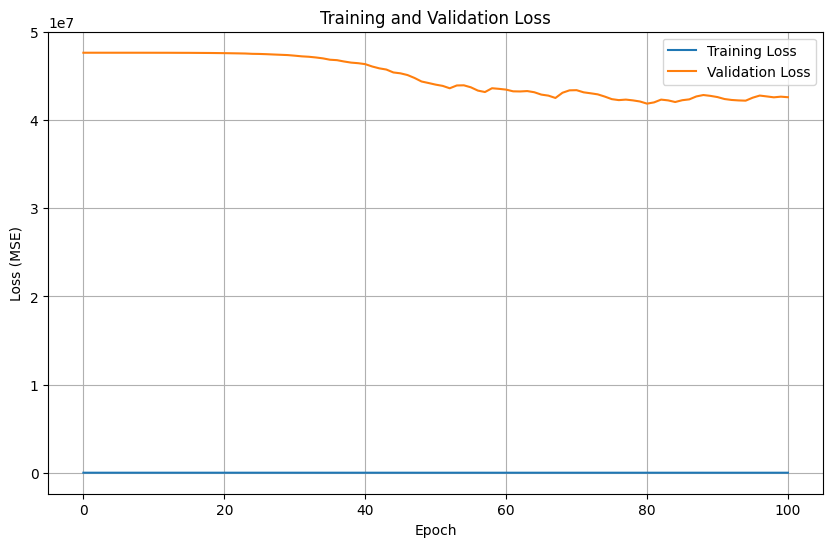

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(10, 6))
sns.lineplot(data=history.history, x=history.epoch, y='loss', label='Training Loss')
sns.lineplot(data=history.history, x=history.epoch, y='val_loss', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
results_df = pd.DataFrame(results)
display(results_df)

,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
0,LinearRegression,6.639549e-01,0.814834,0.264794,9.350276e-01,9.350276e-01,0.140592
1,Ridge,6.564684e-01,0.810227,0.264855,9.357602e-01,9.358925e-01,0.147259
2,Lasso,8.107036e-01,0.900391,0.244180,9.206673e-01,9.226995e-01,0.208426
3,DecisionTreeRegressor,1.191183e+00,1.091413,0.034847,8.834348e-01,8.834369e-01,0.000006
4,RandomForestRegressor,5.521640e+00,2.349817,0.045813,4.596708e-01,4.598006e-01,0.000004
5,GradientBoostingRegressor,2.829662e-01,0.531946,0.075096,9.723099e-01,9.723101e-01,0.045231
6,AdaBoostRegressor,1.540193e+01,3.924529,2.556713,-5.071812e-01,1.519507e-02,2.511941
7,SVR,9.996714e+00,3.161758,0.203304,2.175499e-02,2.383641e-02,0.047375
8,KNeighborsRegressor,3.696729e+00,1.922688,0.146588,6.382505e-01,6.389275e-01,0.002607
9,LGBMRegressor,4.757643e+05,689.756710,28.819281,-4.655571e+04,-4.652608e+04,0.001632


In [19]:
print("Model Performance Comparison:")
display(results_df.sort_values(by='rmse'))

Model Performance Comparison:


,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
14,RandomForestRegressor,2.372765e-01,0.487110,0.034969,9.767809e-01,9.767900e-01,0.007243
17,GradientBoostingRegressor,2.770273e-01,0.526334,0.029506,9.728910e-01,9.728910e-01,0.000408
5,GradientBoostingRegressor,2.829662e-01,0.531946,0.075096,9.723099e-01,9.723101e-01,0.045231
1,Ridge,6.564684e-01,0.810227,0.264855,9.357602e-01,9.358925e-01,0.147259
0,LinearRegression,6.639549e-01,0.814834,0.264794,9.350276e-01,9.350276e-01,0.140592
13,SVR,7.098778e-01,0.842542,0.320962,9.305337e-01,9.347286e-01,0.298368
2,Lasso,8.107036e-01,0.900391,0.244180,9.206673e-01,9.226995e-01,0.208426
3,DecisionTreeRegressor,1.191183e+00,1.091413,0.034847,8.834348e-01,8.834369e-01,0.000006
12,XGBRegressor,1.878551e+00,1.370602,0.035623,8.161713e-01,8.162102e-01,0.002671
15,KNeighborsRegressor,3.131866e+00,1.769708,0.140400,6.935260e-01,6.939392e-01,0.002624


In [20]:
print("\nSummary of Model Performance:")
print("Models with lowest RMSE and highest R2 generally perform best.")
print("\nTop performing models based on RMSE (lower is better):")
display(results_df.sort_values(by='rmse').head())

print("\nTop performing models based on R2 (higher is better):")
display(results_df.sort_values(by='r2', ascending=False).head())


Summary of Model Performance:
Models with lowest RMSE and highest R2 generally perform best.

Top performing models based on RMSE (lower is better):


,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
14,RandomForestRegressor,0.237276,0.487110,0.034969,0.976781,0.976790,0.007243
17,GradientBoostingRegressor,0.277027,0.526334,0.029506,0.972891,0.972891,0.000408
5,GradientBoostingRegressor,0.282966,0.531946,0.075096,0.972310,0.972310,0.045231
1,Ridge,0.656468,0.810227,0.264855,0.935760,0.935892,0.147259
0,LinearRegression,0.663955,0.814834,0.264794,0.935028,0.935028,0.140592



Top performing models based on R2 (higher is better):


,model_name,mse,rmse,mae,r2,explained_variance,median_absolute_error
14,RandomForestRegressor,0.237276,0.487110,0.034969,0.976781,0.976790,0.007243
17,GradientBoostingRegressor,0.277027,0.526334,0.029506,0.972891,0.972891,0.000408
5,GradientBoostingRegressor,0.282966,0.531946,0.075096,0.972310,0.972310,0.045231
1,Ridge,0.656468,0.810227,0.264855,0.935760,0.935892,0.147259
0,LinearRegression,0.663955,0.814834,0.264794,0.935028,0.935028,0.140592


In [21]:
results_df.to_csv('/content/drive/MyDrive/models/noise_predictor/all_model_results.csv', index=False)
print("All model results saved to /content/drive/MyDrive/models/noise_predictor/all_model_results.csv")

All model results saved to /content/drive/MyDrive/models/noise_predictor/all_model_results.csv
